© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note on Figures**:
Figures generated using this notebook that are **identical to or derivative of those published in**:  
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in press**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such figures requires explicit permission from the journal.   

Figures that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

Close pair index check:
Line 3: lambda0=299.870000  coarse=299.870814  idx_ref=965
Line 4: lambda0=299.880000  coarse=299.880637  idx_ref=1030

indx=0 (t=0.0 s)

Per-line centre residuals: (method - truth)
Units: nm  (and pm in parentheses)

Line | truth [nm]      LineFit [nm] (pm)      Parab [nm] (pm)        CoG [nm] (pm)          FFT [nm] (pm)          Poly6w [nm] (pm)
--------------------------------------------------------------------------------------------------------------------------------------------
   1 | 299.775644    0.000007 ( 0.006761)   -0.000018 (-0.017837)   -0.000008 (-0.008289)   -0.000019 (-0.019415)   -0.000045 (-0.045170)
   2 | 299.812284    0.000103 ( 0.102514)   -0.000084 (-0.083885)    0.000017 ( 0.016939)   -0.000156 (-0.156428)   -0.000080 (-0.080307)
   3 | 299.844567    0.000049 ( 0.049473)    0.000360 ( 0.359977)    0.000073 ( 0.073265)    0.000187 ( 0.187135)   -0.000033 (-0.033140)
   4 | 299.870945   -0.000008 (-0.007606)   -0.000208 (-0.207825)    0.

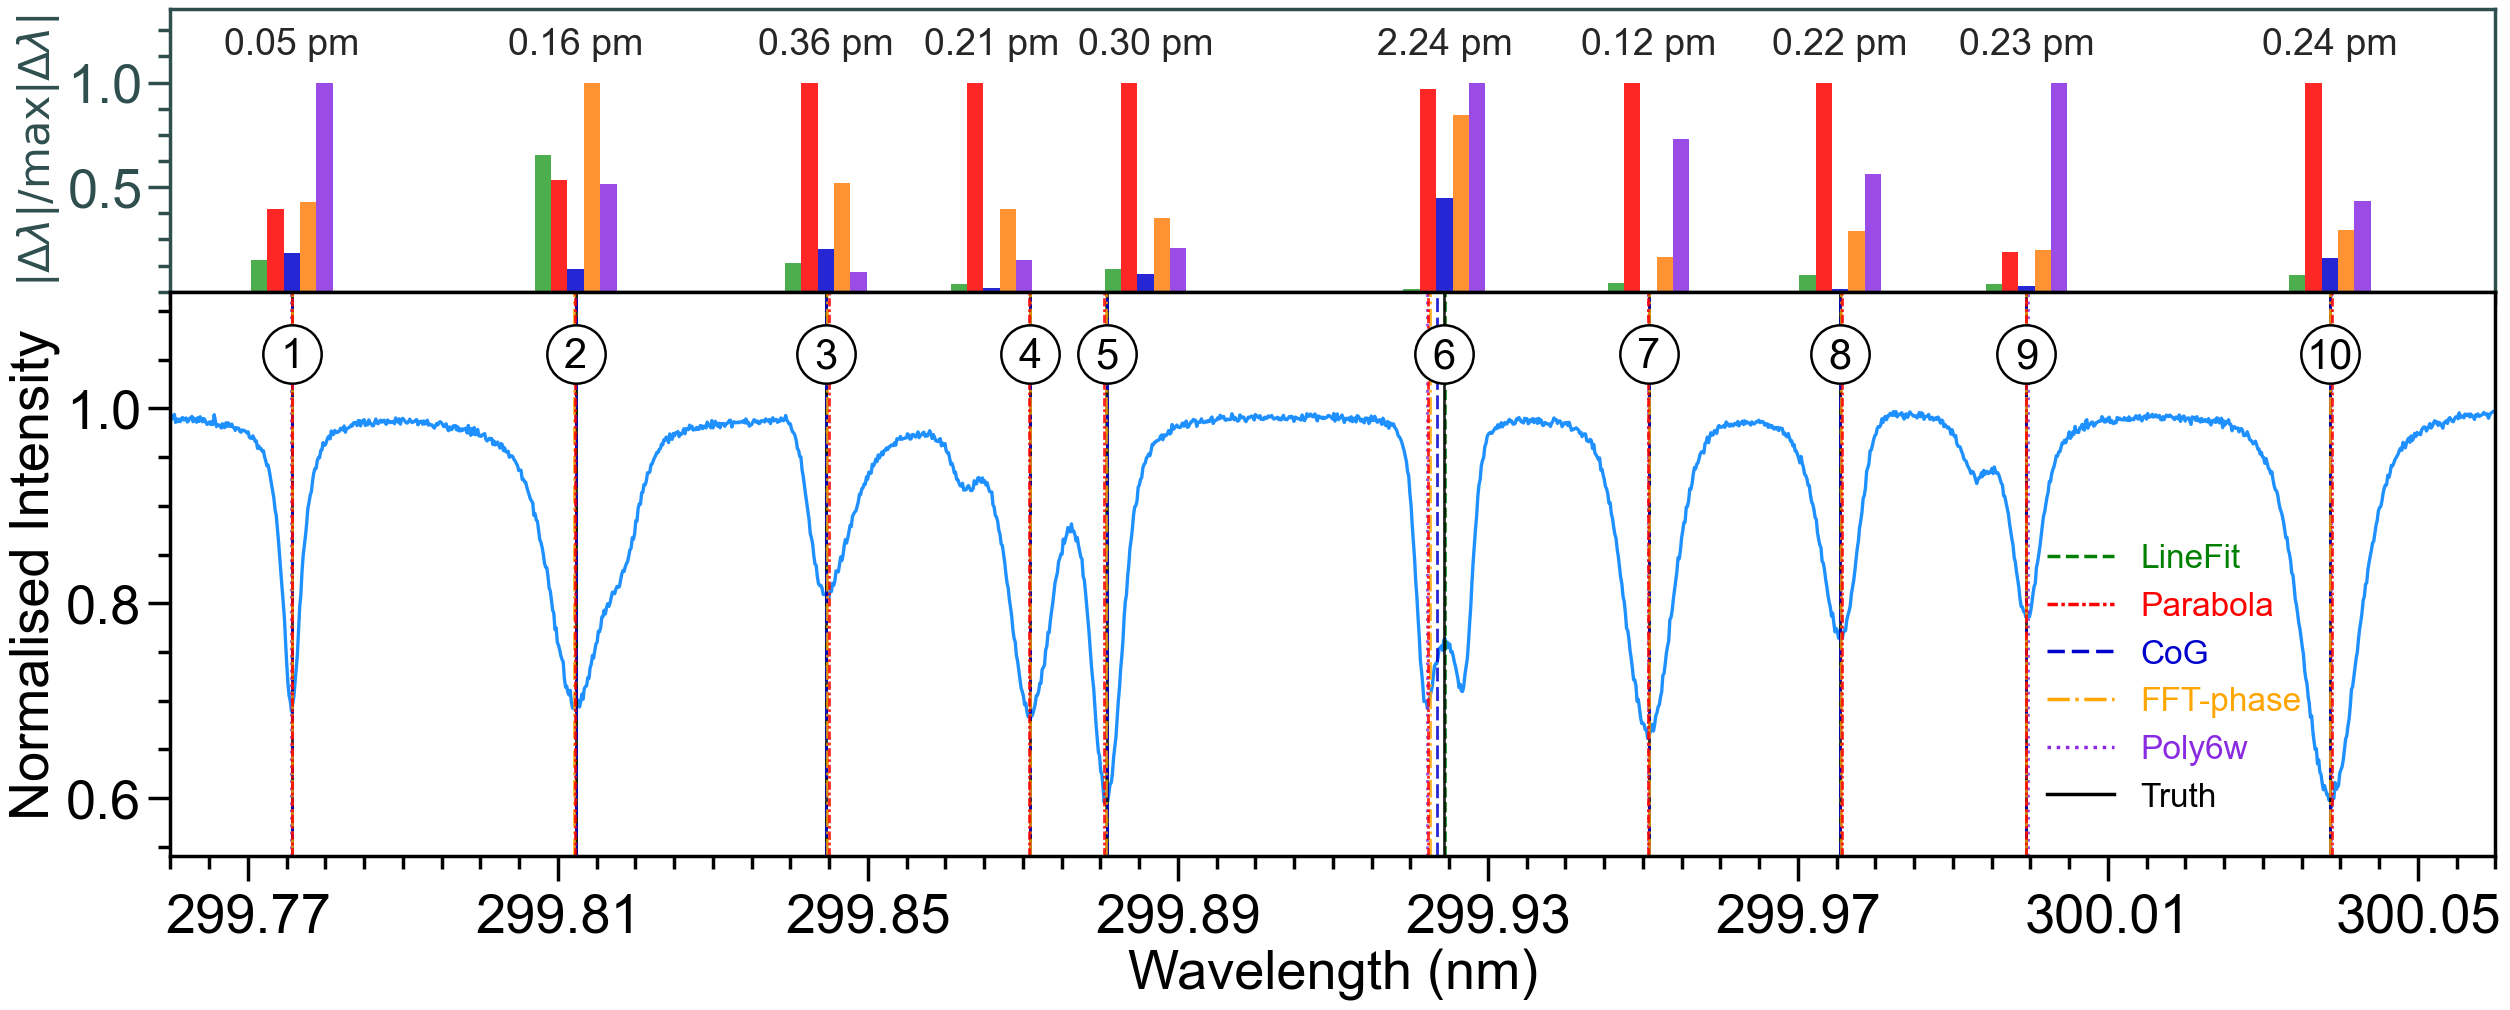

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/Figure3_methods_comparison.pdf'


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 3: Accuracy comparison of line-centre estimators on the synthetic NUV testbed
======================================================================================

Purpose
-------
Generate the manuscript Figure 3 comparing line-centre estimates from:

  1) LineFit centres (read from the LineFit CSV output calculated in Figure2.ipynb)
  2) Parabolic minimum (3-point quadratic around the local minimum)
  3) COG (centre-of-gravity of the absorption depression)
  4) FFT-phase centroid (reference-free k=1 Fourier phase of the depression)
  5) Poly6w (weighted polynomial core fit with N=7 points and order=6 polynomial)

Figure layout (kept identical to the manuscript)
------------------------------------------------
Top panel:
  - Normalised absolute residuals |Δλ| / max(|Δλ|) per line,
    displayed as grouped bars per method.
  - Text above each line group: absolute max |Δλ| for that line (pm).

Bottom panel:
  - Synthetic spectrum I(λ) at time index `indx`
  - Vertical markers for:
      * LineFit centres (green dashed)
      * Truth centres (black solid)
      * Parabola (red dashed)
      * CoG (blue dotted)
      * FFT-phase (orange dash-dot)
      * Poly6w (violet dotted)

Inputs (paper-frozen values)
----------------------------
Must be defined:
  - indx : int
      Time index into synthetic cube.
  - per_line_window_size : length-10 iterable of ints
      Half-window (pixels) per line for the fast estimators.
  - LineFit output files in ./Files (calculated in Figure2.ipynb):
      extracted_parameters_date_id_pixel_<indx>.csv
      fitted_spectra_date_id_pixel_<indx>.fits   (not used here; only CSV is used)

Notes
-----
• Close-pair handling (lines 4–5; 0-indexed (3,4)) is implemented via a valley split
  during coarse localisation (ownership control).
• This script is intentionally kept "clean" (few switches) so the figure remains stable
  and reproducible.

Dependencies
------------
numpy, matplotlib, astropy, scipy (uniform_filter1d, find_peaks), WaLSAtools (WaLSA_save_pdf)

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

from WaLSAtools import WaLSA_save_pdf  # type: ignore


# =============================================================================
# USER SETTINGS (edit here)
# =============================================================================
fits_path = "synthetic_nuv_testbed.fits"

# Time index to plot (0-based)
indx = 0

# Per-line half-window in *pixels* used for the fast estimators (length 10)
per_line_window_size = [10, 10, 10, 10, 10, 28, 18, 10, 10, 20]

# LineFit outputs (generated by Figure 2 script / LineFit run)
FILES_DIR = "Files"
csv_path  = f"{FILES_DIR}/extracted_parameters_date_id_pixel_{indx}.csv"
# fits_path_linefit = f"{FILES_DIR}/fitted_spectra_date_id_pixel_{indx}.fits"  # not used in this figure

# Output figure path
FIG_DIR = "Figures"
pdf_path = f"{FIG_DIR}/Figure3_methods_comparison.pdf"

# Ensure output directories exist (no effect on results)
os.makedirs(FILES_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


# =============================================================================
# Helpers
# =============================================================================
def local_continuum_estimate(y):
    """Robust local continuum estimate from the top 20% of samples in the window."""
    y = np.asarray(y, float)
    if y.size == 0 or np.all(~np.isfinite(y)):
        return np.nan
    y = y[np.isfinite(y)]
    if y.size == 0:
        return np.nan
    top = np.sort(y)[int(0.8 * len(y)):]
    return np.median(top) if top.size else np.max(y)


def extract_parabolic_min_robust(wl, I, idx0, half_win=16, max_recenter=2):
    """
    Parabolic minimum estimator:
      1) find local minimum in a window (with limited recentering)
      2) fit quadratic to 3 points around the minimum
      3) return vertex position (-b/2a) in nm
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size

    center = int(idx0)

    for _ in range(max_recenter + 1):
        lo = max(0, center - half_win)
        hi = min(n, center + half_win + 1)
        x = wl[lo:hi]
        y = I[lo:hi]

        if np.any(~np.isfinite(y)):
            m = np.nanmedian(y)
            if not np.isfinite(m):
                return np.nan
            y = np.where(np.isfinite(y), y, m)

        j = int(np.argmin(y))

        if j <= 0 or j >= (y.size - 1):
            center = lo + j
            continue

        x3 = x[j-1:j+2]
        y3 = y[j-1:j+2]
        a, b, c = np.polyfit(x3, y3, 2)
        if (not np.isfinite(a)) or abs(a) < 1e-30:
            return np.nan
        return -b / (2*a)

    return np.nan


def extract_cog(wl, I, idx0, half_win=26):
    """
    Standard COG of absorption depression:
      D = 1 - I/Ic  (clipped to >= 0)
      centre = sum(wl * D) / sum(D)
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size
    lo = max(0, idx0 - half_win)
    hi = min(n, idx0 + half_win + 1)
    x = wl[lo:hi]
    y = I[lo:hi]

    Ic = local_continuum_estimate(y)
    if not np.isfinite(Ic) or Ic <= 0:
        return np.nan

    D = 1.0 - (y / Ic)
    D = np.clip(D, 0.0, None)
    denom = np.sum(D)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    return np.sum(x * D) / denom


def nearest_index(w, x):
    """Nearest index of wavelength array w to target wavelength x."""
    return int(np.argmin(np.abs(np.asarray(w, float) - float(x))))


# =============================================================================
# FFT/Lpffpy-style reference-free Fourier centroid
# =============================================================================
def _fft_phase_position_index(profile, prefer_center=True):
    """
    Reference-free k=1 phase position in index units.
    profile: 1D array (window)
    Returns fractional index in [0, N) (or near centre if prefer_center=True).
    """
    p = np.asarray(profile, float)
    N = p.size
    if N < 8 or (not np.isfinite(p).all()):
        return np.nan

    # remove DC so the k=1 phase reflects where the "bump" is
    p = p - np.mean(p)

    F1 = np.fft.fft(p.astype(np.float64))[1]
    if np.abs(F1) < 1e-20:
        return np.nan

    # correct mapping for delta-like bump: angle(F1) = -2π n0/N
    pos = (-N / (2.0 * np.pi)) * np.angle(F1)

    # wrap to [0, N)
    pos = float(np.mod(pos, N))

    if prefer_center:
        mid = 0.5 * (N - 1)
        candidates = np.array([pos, pos + N, pos - N], float)
        pos = float(candidates[np.argmin(np.abs(candidates - mid))])

    return pos


def extract_fourier_phase_center_single(
    wl, I, idx0,
    wl_ref=None, I_ref=None, idx0_ref=None,
    half_win=30,
    apodize=True,
    x0_ref_center_nm=None,
):
    """
    FFT-phase centroid:
      - estimate local continuum Ic
      - build absorption depression D = 1 - I/Ic (>=0)
      - optionally apodize D with Hanning
      - compute k=1 FFT phase position -> convert to wavelength
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size

    lo = max(0, int(idx0) - int(half_win))
    hi = min(n, int(idx0) + int(half_win) + 1)
    x = wl[lo:hi]
    y = I[lo:hi]

    if x.size < 10 or y.size != x.size:
        return np.nan

    if np.any(~np.isfinite(y)):
        m = np.nanmedian(y)
        if not np.isfinite(m):
            return np.nan
        y = np.where(np.isfinite(y), y, m)

    Ic = local_continuum_estimate(y)
    if (not np.isfinite(Ic)) or Ic <= 0:
        return np.nan

    D = 1.0 - (y / Ic)
    D = np.clip(D, 0.0, None)
    if (not np.isfinite(D).all()) or np.sum(D) <= 0:
        return np.nan

    if apodize:
        D = D * np.hanning(D.size)

    pos = _fft_phase_position_index(D, prefer_center=True)
    if not np.isfinite(pos):
        return np.nan

    step = float(x[1] - x[0])
    return float(x[0] + pos * step)


# =============================================================================
# Poly6w weighted polynomial method
# =============================================================================
def extract_polycore_weighted(
    wl,
    I,
    idx0,
    *,
    N=7,
    poly_order=6,
    max_recenter=2,
    weight_eps=0.1,
    return_intensity=True,
):
    """
    Weighted polynomial core fit:
      - find local minimum with limited recentering
      - fit polynomial of given order around the minimum (shifted coordinates)
      - weights favour points near the minimum (1/(eps+|Δλ|))
      - find minimum of polynomial (via roots of derivative + edge checks)
    """
    wl = np.asarray(wl, float)
    I = np.asarray(I, float)
    n = wl.size
    if n < 5:
        return (np.nan, np.nan) if return_intensity else np.nan

    center = int(idx0)

    for _ in range(max_recenter + 1):
        half_win = max(int(N) + 2, 6)
        lo = max(0, center - half_win)
        hi = min(n, center + half_win + 1)

        xw = wl[lo:hi]
        yw = I[lo:hi]

        if xw.size < (2 * N + 1):
            return (np.nan, np.nan) if return_intensity else np.nan

        if np.any(~np.isfinite(yw)):
            m = np.nanmedian(yw)
            if not np.isfinite(m):
                return (np.nan, np.nan) if return_intensity else np.nan
            yw = np.where(np.isfinite(yw), yw, m)

        j_local = int(np.argmin(yw))
        idx_min = lo + j_local

        if j_local <= 0 or j_local >= (yw.size - 1):
            center = idx_min
            continue

        lo2 = max(0, idx_min - int(N))
        hi2 = min(n, idx_min + int(N) + 1)

        x = wl[lo2:hi2]
        y = I[lo2:hi2]

        if x.size < (poly_order + 1):
            return (np.nan, np.nan) if return_intensity else np.nan

        if np.any(~np.isfinite(y)):
            m = np.nanmedian(y)
            if not np.isfinite(m):
                return (np.nan, np.nan) if return_intensity else np.nan
            y = np.where(np.isfinite(y), y, m)

        x_min = float(wl[idx_min])
        w = 1.0 / (float(weight_eps) + np.abs(x - x_min))
        if not np.isfinite(w).all():
            return (np.nan, np.nan) if return_intensity else np.nan
        w = w / (np.nanmax(w) + 1e-30)

        x_shift = x - x_min
        try:
            coeffs = np.polyfit(x_shift, y, int(poly_order), w=w)
        except Exception:
            return (np.nan, np.nan) if return_intensity else np.nan

        if not np.isfinite(coeffs).all():
            return (np.nan, np.nan) if return_intensity else np.nan

        dcoeffs = np.polyder(coeffs)
        roots = np.roots(dcoeffs)

        r = roots[np.isreal(roots)].real
        xmin_s = float(np.min(x_shift))
        xmax_s = float(np.max(x_shift))
        r = r[(r >= xmin_s) & (r <= xmax_s)]

        candidates = np.r_[r, xmin_s, xmax_s]
        pvals = np.polyval(coeffs, candidates)
        if pvals.size == 0 or np.all(~np.isfinite(pvals)):
            return (np.nan, np.nan) if return_intensity else np.nan

        k = int(np.nanargmin(pvals))
        x_best_shift = float(candidates[k])
        center_nm = float(x_min + x_best_shift)

        if not return_intensity:
            return center_nm

        I_center = float(np.polyval(coeffs, x_best_shift))
        return center_nm, I_center

    return (np.nan, np.nan) if return_intensity else np.nan


# =============================================================================
# Close-pair-safe coarse localisation (ownership split by valley)
# =============================================================================
def coarse_centers_closepair_safe(
    wl, I, lambda0_nm,
    search_half_win=120,
    smooth=3,
    close_pairs=[(3, 4)],
    peak_distance=2,
    height_rel=0.05,
    valley_pad_bins=0,
):
    """
    Coarse localisation of each line minimum starting from rest wavelengths lambda0_nm.
    For close pairs, split “ownership” by the inter-line valley to prevent swapping.
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    lam0 = np.asarray(lambda0_nm, float)
    nlines = lam0.size
    n = wl.size

    y = np.nan_to_num(I, nan=np.nanmedian(I) if np.any(np.isfinite(I)) else 0.0)
    y01 = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-12)
    sm = uniform_filter1d(y01, size=int(smooth))
    inv = 1.0 - sm

    def pick_peak_in_interval(i, lo, hi):
        lo = int(max(0, lo))
        hi = int(min(n - 1, hi))
        if hi <= lo + 4:
            return int(np.clip(nearest_index(wl, lam0[i]), lo, hi))

        seg = inv[lo:hi+1]
        if seg.size < 10 or (not np.isfinite(seg).all()):
            return int(lo + np.nanargmax(seg))

        thr = float(height_rel * np.nanmax(seg))
        pks, _props = find_peaks(seg, distance=int(peak_distance), height=thr)
        if pks.size == 0:
            return int(lo + np.nanargmax(seg))

        pks_abs = lo + pks
        dist = np.abs(wl[pks_abs] - lam0[i])
        height = inv[pks_abs]
        score = dist + 0.10 * (1.0 - height / (np.nanmax(height) + 1e-12))
        return int(pks_abs[np.argmin(score)])

    idx = np.full(nlines, -1, dtype=int)
    for i in range(nlines):
        idx0 = nearest_index(wl, lam0[i])
        lo = max(0, idx0 - int(search_half_win))
        hi = min(n - 1, idx0 + int(search_half_win))
        idx[i] = pick_peak_in_interval(i, lo, hi)

    for (i, j) in close_pairs:
        ii = nearest_index(wl, lam0[i])
        jj = nearest_index(wl, lam0[j])
        a = min(ii, jj)
        b = max(ii, jj)

        if b <= a + 2:
            valley = (a + b) // 2
        else:
            seg = inv[a:b+1]
            valley = int(a + np.argmin(seg))

        valley_L = max(0, valley - int(valley_pad_bins))
        valley_R = min(n - 1, valley + int(valley_pad_bins))

        lo_pair = max(0, a - int(search_half_win))
        hi_pair = min(n - 1, b + int(search_half_win))

        idx[i] = pick_peak_in_interval(i, lo_pair, valley_L)
        idx[j] = pick_peak_in_interval(j, valley_R, hi_pair)

    centers_nm = wl[idx].astype(float)
    return centers_nm, idx


# =============================================================================
# Read synthetic FITS testbed
# =============================================================================
with fits.open(fits_path) as hdul:
    spectra        = np.asarray(hdul[0].data)                  # (nt, nw)
    wavelengths    = np.asarray(hdul["WAVELENGTH"].data)       # (nw,)
    time_s         = np.asarray(hdul["TIME"].data)             # (nt,)
    lambda0_nm     = np.asarray(hdul["LAMBDA0"].data)          # (10,)
    center_true_nm = np.asarray(hdul["CENTER_TRUE"].data)      # (10, nt)

I = spectra[indx]
cent_true = center_true_nm[:, indx]
refwavelength = lambda0_nm.copy()
close_pairs = [(3, 4)]

# Coarse localisation (close-pair-safe)
coarse_center, idx_ref = coarse_centers_closepair_safe(
    wl=wavelengths, I=I, lambda0_nm=lambda0_nm,
    search_half_win=120, smooth=3,
    close_pairs=close_pairs,
    peak_distance=2, height_rel=0.05,
    valley_pad_bins=0,
)

# =============================================================================
# Read LineFit centres (nm) from the LineFit CSV output
# =============================================================================
rows = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
mask_pix = (rows["Spatial_Pixel"] == indx) if "Spatial_Pixel" in rows.dtype.names else np.ones(len(rows), dtype=bool)

col_candidates = ["Fitted_centre_nm", "Fitted_centre__nm_", "Fitted_centre_(nm)", "Fitted_centre_nm_"]
fitted_col = None
for c in col_candidates:
    if c in rows.dtype.names:
        fitted_col = c
        break
if fitted_col is None:
    for c in rows.dtype.names:
        if ("Fitted" in c) and ("centre" in c):
            fitted_col = c
            break
if fitted_col is None:
    raise ValueError(f"Could not find fitted-centre column in CSV. Columns: {rows.dtype.names}")

fitted_centres = np.asarray(rows[fitted_col][mask_pix], dtype=float)

# =============================================================================
# Measure centres (nm) with the fast methods
# =============================================================================
n_lines = lambda0_nm.size
cent_parab = np.full(n_lines, np.nan, float)
cent_cog   = np.full(n_lines, np.nan, float)
cent_fft   = np.full(n_lines, np.nan, float)
cent_poly  = np.full(n_lines, np.nan, float)

POLY_N = 7
POLY_ORDER = 6
POLY_WEIGHT_EPS = 0.1

for i in range(n_lines):
    hw = int(per_line_window_size[i])

    cent_parab[i] = extract_parabolic_min_robust(wavelengths, I, idx_ref[i], half_win=hw)
    cent_cog[i]   = extract_cog(wavelengths, I, idx_ref[i], half_win=hw)

    cent_fft[i] = extract_fourier_phase_center_single(
        wl=wavelengths, I=I, idx0=idx_ref[i],
        wl_ref=wavelengths, I_ref=I, idx0_ref=idx_ref[i],
        half_win=hw, apodize=True,
        x0_ref_center_nm=None,
    )

    cent_poly[i] = extract_polycore_weighted(
        wavelengths, I, idx_ref[i],
        N=POLY_N, poly_order=POLY_ORDER, max_recenter=2,
        weight_eps=POLY_WEIGHT_EPS,
        return_intensity=False,
    )

# =============================================================================
# Console prints (unchanged)
# =============================================================================
print("Close pair index check:")
for i in [3, 4]:
    print(f"Line {i}: lambda0={lambda0_nm[i]:.6f}  coarse={coarse_center[i]:.6f}  idx_ref={idx_ref[i]}")

print(f"\nindx={indx} (t={time_s[indx]:.1f} s)")
print("\nPer-line centre residuals: (method - truth)")
print("Units: nm  (and pm in parentheses)\n")
print("Line | truth [nm]      LineFit [nm] (pm)      Parab [nm] (pm)        CoG [nm] (pm)          FFT [nm] (pm)          Poly6w [nm] (pm)")
print("-"*140)

for i in range(n_lines):
    dw = fitted_centres[i] - cent_true[i] if np.isfinite(fitted_centres[i]) else np.nan
    dp = cent_parab[i]     - cent_true[i] if np.isfinite(cent_parab[i])     else np.nan
    dc = cent_cog[i]       - cent_true[i] if np.isfinite(cent_cog[i])       else np.nan
    df = cent_fft[i]       - cent_true[i] if np.isfinite(cent_fft[i])       else np.nan
    d6 = cent_poly[i]      - cent_true[i] if np.isfinite(cent_poly[i])      else np.nan

    print(
        f"{i+1:4d} | {cent_true[i]:.6f}   "
        f"{dw: .6f} ({dw*1e3: .6f})   "
        f"{dp: .6f} ({dp*1e3: .6f})   "
        f"{dc: .6f} ({dc*1e3: .6f})   "
        f"{df: .6f} ({df*1e3: .6f})   "
        f"{d6: .6f} ({d6*1e3: .6f})"
    )

max_walsa_pm = np.nanmax(np.abs(fitted_centres - cent_true)) * 1e3
max_parab_pm = np.nanmax(np.abs(cent_parab     - cent_true)) * 1e3
max_cog_pm   = np.nanmax(np.abs(cent_cog       - cent_true)) * 1e3
max_fft_pm   = np.nanmax(np.abs(cent_fft       - cent_true)) * 1e3
max_poly_pm  = np.nanmax(np.abs(cent_poly      - cent_true)) * 1e3

print("\nMax |Δλ| (pm):")
print(f"  LineFit: {max_walsa_pm:.3f}   Parab: {max_parab_pm:.3f}   CoG: {max_cog_pm:.3f}   FFT: {max_fft_pm:.3f}   Poly6w: {max_poly_pm:.3f}")

# =============================================================================
# Figure 3 plotting (STYLE + LOGIC KEPT IDENTICAL)
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 40,
    'axes.titlesize': 39,
    'axes.labelsize': 39,
    'xtick.labelsize': 39,
    'ytick.labelsize': 39,
    'legend.fontsize': 39,
    'figure.titlesize': 40,
    'axes.grid': False,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'font.weight': 500,
    'axes.titleweight': 500,
    'axes.labelweight': 500
})

plt.rc('axes', linewidth=2.5)
plt.rc('lines', linewidth=1.5)

res_unit = "pm"
scale = 1000.0

d_walsa = (np.asarray(fitted_centres, float) - np.asarray(cent_true, float)) * scale
d_parab = (np.asarray(cent_parab,     float) - np.asarray(cent_true, float)) * scale
d_cog   = (np.asarray(cent_cog,       float) - np.asarray(cent_true, float)) * scale
d_fft   = (np.asarray(cent_fft,       float) - np.asarray(cent_true, float)) * scale
d_poly  = (np.asarray(cent_poly,      float) - np.asarray(cent_true, float)) * scale

x0 = np.asarray(cent_true, float)
n_lines = x0.size

abs_walsa = np.abs(d_walsa)
abs_parab = np.abs(d_parab)
abs_cog   = np.abs(d_cog)
abs_fft   = np.abs(d_fft)
abs_poly  = np.abs(d_poly)

ABS = np.vstack([abs_walsa, abs_parab, abs_cog, abs_fft, abs_poly]).T  # (n_lines, 5)

mx = np.nanmax(ABS, axis=1)
mx_safe = np.where(np.isfinite(mx) & (mx > 0), mx, np.nan)
NORM = ABS / mx_safe[:, None]

fig, (ax_res, ax_spec) = plt.subplots(
    2, 1, figsize=(30, 11), sharex=True,
    gridspec_kw={"height_ratios": [2.5, 5.0], "hspace": 0.0}
)

ax_res.axhline(0.0, lw=1.0, alpha=0.6)

x0_f = np.sort(x0[np.isfinite(x0)])
if x0_f.size >= 2:
    med_sep = np.median(np.diff(x0_f))
else:
    med_sep = (np.nanmax(x0) - np.nanmin(x0)) / max(n_lines, 1)

bar_w = 0.08 * med_sep
dx = bar_w
offs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0]) * dx  # 5 methods

labels = ["LineFit", "Parabola", "CoG", "FFT-phase", "Poly6w"]
colors = ["tab:green", "red", "mediumblue", "tab:orange", "blueviolet"]

# Visual spacing tweak for the close pair so bars don’t collide in the top panel
shiftbars_nm = -0.005
i_shift = 3
shiftbars2_nm = 0.005
i_shift2 = 4

first = True
for i in range(n_lines):
    if not np.isfinite(x0[i]):
        continue

    x_base = x0[i] + (shiftbars_nm if i == i_shift else (shiftbars2_nm if i == i_shift2 else 0.0))

    vals = NORM[i]
    for j in range(5):
        if np.isfinite(vals[j]):
            ax_res.bar(
                x_base + offs[j],
                vals[j],
                width=bar_w,
                bottom=0.0,
                alpha=0.85,
                label=labels[j] if first else None,
                color=colors[j] if j < len(colors) else None,
            )
    first = False

axescolor = "darkslategray"

ax_res.set_ylabel(r"$|\Delta\lambda|/\max|\Delta\lambda|$", fontsize=31, color=axescolor)
ax_res.set_ylim(0.0, 1.35)
ax_res.tick_params(axis="both", which="major", length=16, width=2.5, pad=4, colors=axescolor)
ax_res.tick_params(axis="both", which="minor", length=9, width=2.5, colors=axescolor)
ax_res.yaxis.set_minor_locator(AutoMinorLocator(4))

ax_res.spines["top"].set_color(axescolor)
ax_res.spines["right"].set_color(axescolor)
ax_res.spines["left"].set_color(axescolor)
ax_res.spines["bottom"].set_color(axescolor)

ax_res.set_yticks(np.arange(0.5, 1.35, 0.5))

for i in range(n_lines):
    x_base = x0[i] + (shiftbars_nm if i == i_shift else (shiftbars2_nm if i == i_shift2 else 0.0))
    if np.isfinite(x0[i]) and np.isfinite(mx[i]) and mx[i] > 0:
        ax_res.text(
            x_base,
            1.10,
            f"{mx[i]:.2f} {res_unit}",
            ha="center",
            va="bottom",
            fontsize=27,
            rotation=0,
            alpha=0.85,
            clip_on=False,
        )

# Bottom spectrum panel
ax_spec.plot(wavelengths, I, color="DodgerBlue", lw=2.4)

# Poly centres (violet dotted)
for cc in cent_poly:
    if np.isfinite(cc):
        ax_spec.axvline(float(cc), linestyle=":", color="blueviolet", alpha=0.85, lw=2.0)

# LineFit centres (green dashed)
for xc in fitted_centres:
    if np.isfinite(xc):
        ax_spec.axvline(float(xc), linestyle="--", color="green", alpha=0.85, lw=2.0)

# Truth centres (black solid)
for rw in cent_true:
    ax_spec.axvline(float(rw), linestyle="-", color="black", alpha=0.85, lw=2.0)

# CoG centres (blue dotted)
for cc in cent_cog:
    if np.isfinite(cc):
        ax_spec.axvline(float(cc), linestyle=(0, (5, 2)), color="mediumblue", alpha=0.85, lw=2.0)

# FFT-phase centres (orange dash-dot)
for cc in cent_fft:
    if np.isfinite(cc):
        ax_spec.axvline(float(cc), linestyle="-.", color="orange", alpha=0.85, lw=2.0)

# Parabolic centres (red dashed)
for cc in cent_parab:
    if np.isfinite(cc):
        ax_spec.axvline(float(cc), linestyle=(0, (3, 1, 1, 1)), color="red", alpha=0.85, lw=2.0)

ax_spec.tick_params(axis="y", which="major", length=16, width=2.5, pad=5)
ax_spec.tick_params(axis="x", which="major", length=18, width=2.5, pad=5)
ax_spec.tick_params(axis="x", which="major", pad=8)
ax_spec.tick_params(axis="both", which="minor", length=9, width=2.5)
ax_spec.xaxis.set_minor_locator(AutoMinorLocator(8))
ax_spec.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_spec.set_xlabel("Wavelength (nm)")
ax_spec.set_ylabel("Normalised Intensity")
ax_spec.set_xlim(299.760, 300.060)
ax_spec.set_xticks(np.arange(299.770, 300.060, 0.04))

ax_spec.set_ylim(0.54, 1.12)
ylim = (0.54, 1.12)

# Numbered circle labels at truth centres
y_circle = ylim[1] - 0.110 * (ylim[1] - ylim[0])
y_text   = ylim[1] - 0.115 * (ylim[1] - ylim[0])

for j, rw in enumerate(cent_true):
    if np.isfinite(rw):
        ax_spec.plot(
            float(rw), y_circle,
            marker="o",
            markersize=42,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.8,
            linestyle="None",
            zorder=6,
        )
        ax_spec.text(
            float(rw), y_text, f"{j+1}",
            fontsize=30,
            ha="center",
            va="center",
            color="black",
            zorder=7,
        )

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color="green",      linestyle="--", lw=2.5, label="LineFit"),
    Line2D([0], [0], color="red",        linestyle=(0, (3, 1, 1, 1)), lw=2.5, label="Parabola"),
    Line2D([0], [0], color="mediumblue", linestyle=(0, (5, 2)),  lw=2.5, label="CoG"),
    Line2D([0], [0], color="orange",     linestyle="-.", lw=2.5, label="FFT-phase"),
    Line2D([0], [0], color="blueviolet", linestyle=":",  lw=2.5, label="Poly6w"),
    Line2D([0], [0], color="black",      linestyle="-",  lw=2.5, label="Truth"),
]

leg = ax_spec.legend(
    handles=legend_handles,
    fontsize=24,
    loc="center",
    bbox_to_anchor=(0.862, 0.315),
    ncol=1,
    frameon=False,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
)

for txt, h in zip(leg.get_texts(), legend_handles):
    txt.set_color(h.get_color())

plt.show()

# Save the figure as a single PDF
WaLSA_save_pdf(fig, pdf_path, color_mode='CMYK', dpi=300, bbox_inches='tight', pad_inches=0.1)